In [2]:
# Plot data Rijkswaterstaat stations
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [ ]:
# Function to get NetCDF file path for Pressure Sensors (P_BS)
def get_nc_P_BS(section, bs, period, processing_step='raw'):
    """
    Returns the full path to the NetCDF file for a given section, sensor type+number (BS#), period, and processing step.
    processing_step: 'raw', 'QC', or 'processed'
    """
    # Select folder and filename pattern based on processing_step
    period_num = period.split()[-1]  # e.g., 'period 2' -> '2'
    if processing_step == 'raw':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\raw NetCDF"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) raw data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) raw data - {period}.nc"
    elif processing_step == 'QC':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\QC"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) QC P_rel - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) QC P_air - {period}.nc"
    elif processing_step == 'processed':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\processed"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) processed data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) processed data - {period}.nc"
    else:
        raise ValueError("processing_step must be 'raw', 'QC', or 'processed'")

    # Try RBR first, then Ossi
    if section.lower().startswith('ref'):
        for brand in ['RBR', 'Ossi']:
            fname = ref_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath
    else:
        for brand in ['RBR', 'Ossi']:
            fname = fname_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath

    raise FileNotFoundError(f"File not found for section={section}, bs={bs}, period={period}, processing_step={processing_step}")

# Example usage:
# path = get_nc_P_BS('S1', 'BS2', 'period 2', processing_step='QC')
# print(path)


In [ ]:
nc_waterlevel = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waterlevel_SCHEVNGN.nc'

with xr.open_dataset(nc_waterlevel) as ds_waterlevel:
    ds_waterlevel = ds_waterlevel.sel(t=slice('2024-12-17', '2025-01-10'))
    t_Scheveningen = ds_waterlevel.t  
    zs_Scheveningen = ds_waterlevel.waterlevel / 100

In [ ]:
nc_waterlevel = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waterlevel_HOEKVHLD.nc'

with xr.open_dataset(nc_waterlevel) as ds_waterlevel:
    ds_waterlevel = ds_waterlevel.sel(t_10min=slice('2024-12-17', '2025-01-10'))
    t_HvH = ds_waterlevel.t_10min  
    zs_HvH = ds_waterlevel.waterlevel_10min / 100

    #t_HvH = ds_waterlevel.t_1min  
    #zs_HvH = ds_waterlevel.waterlevel_1min.rolling(t_1min=10, center=True).mean() / 100 # 10 min moving avg


In [3]:
nc = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waves_Eurogeul_E13.nc'
with xr.open_dataset(nc) as ds_waves:
    ds_Eurogeul = ds_waves.sel(t=slice('2024-12-17', '2025-01-10'))

nc = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waves_Hollandse_Kust_Zuid_A.nc'
with xr.open_dataset(nc) as ds_waves:
    ds_HKZA = ds_waves.sel(t=slice('2024-12-17', '2025-01-10'))


In [ ]:
# PRESSURE SENSOR: S3.BS3 ----------------------------------------------------------------------
nc_path = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'
with xr.open_dataset(nc_path) as ds:
    t_full = ds.t_full
    zs_rolling = ds.zs.rolling(t_full=16*60*10, center=True).mean()  # 10 min moving avg
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_P3_a = t_full[::16*60] # every 60 seconds
    zs_P3_a = zs_rolling[::16*60]

    # Save to ds
    ds['zs_rolling'] = zs_rolling
    ds_P3a = ds.sel(t_full=t_P3_a)

nc_path = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 2\Pressure sensor S3 P_BS3 (RBR) processed data - period 2.nc'
with xr.open_dataset(nc_path) as ds:
    t_full = ds.t_full
    zs_rolling = ds.zs.rolling(t_full=16*60*10, center=True).mean()  # 10 min moving avg
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_P3_b = t_full[::16*60] # every 60 seconds
    zs_P3_b = zs_rolling[::16*60]

    # Save to ds
    ds['zs_rolling'] = zs_rolling
    ds_P3b = ds.sel(t_full=t_P3_b)

In [ ]:
storm_times = [ (np.datetime64('2024-12-19T00:00'), np.datetime64('2024-12-20T02:00')),
                (np.datetime64('2024-12-22T01:30'), np.datetime64('2024-12-23T03:00')),
                (np.datetime64('2025-01-01T10:00'), np.datetime64('2025-01-02T23:00')),
                (np.datetime64('2025-01-03T10:00'), np.datetime64('2025-01-04T01:00')),
                (np.datetime64('2025-01-06T12:00'), np.datetime64('2025-01-08T04:00'))   ]

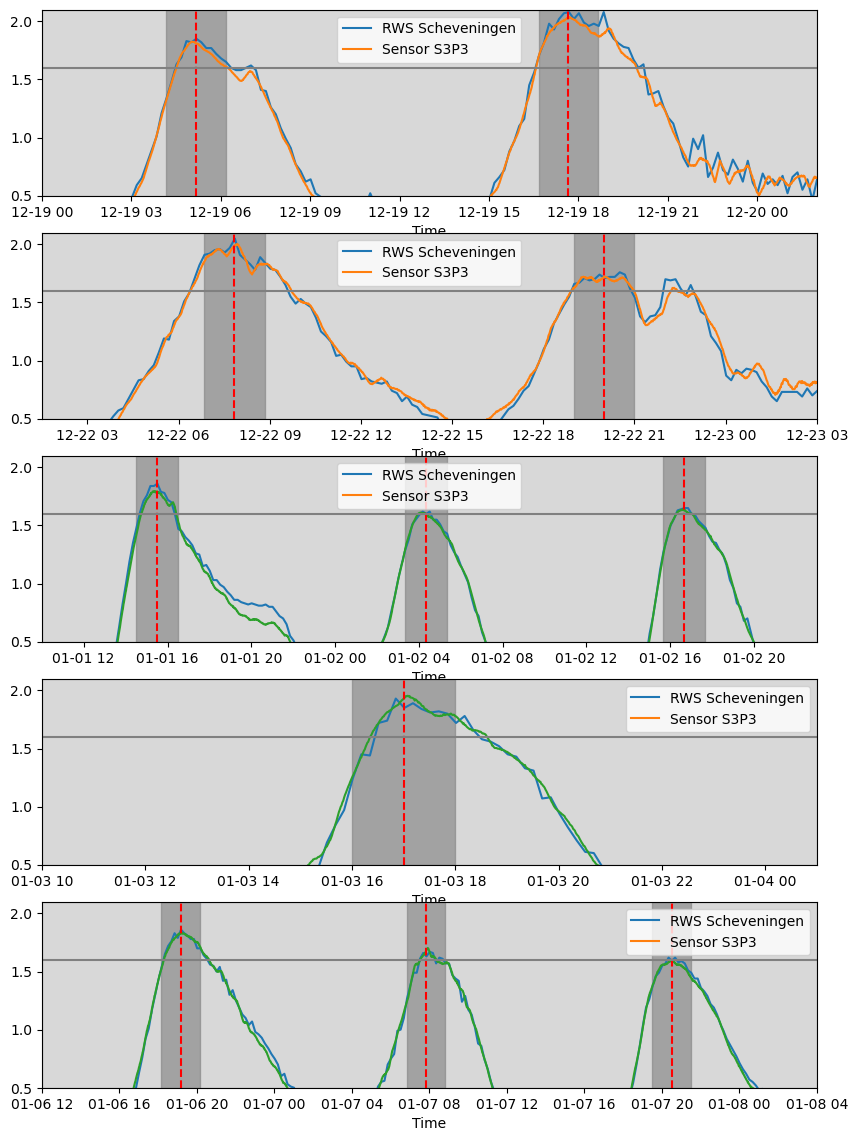

In [ ]:
i_storm = 5
dt_ax = 12

storm_peaks = {
    1: [np.datetime64('2024-12-19T05:10'), np.datetime64('2024-12-19T17:40')],
    2: [np.datetime64('2024-12-22T07:50'), np.datetime64('2024-12-22T20:00')],
    3: [np.datetime64('2025-01-01T15:30'), np.datetime64('2025-01-02T04:20'), np.datetime64('2025-01-02T16:40')],
    4: [np.datetime64('2025-01-03T17:00')],
    5: [np.datetime64('2025-01-06T19:10'), np.datetime64('2025-01-07T07:50'), np.datetime64('2025-01-07T20:30')],
}

def plot_peaks(ax,t,dt_hr):
    ax.axvline(t, color='red', linestyle='--')
    ax.axvspan(t-np.timedelta64(dt_hr, 'h'), t+np.timedelta64(dt_hr, 'h'), color='gray', alpha=0.6)

# Plot figure ------------------------------------------------
fig = plt.figure(figsize=(10, 14))
for i_storm in range(1,6):
    ax = fig.add_subplot(5, 1, i_storm)
    ax.plot(t_Scheveningen - np.timedelta64(9, 'm'), zs_Scheveningen, label='RWS Scheveningen') # make all times 9 minutes earlier: phase lag correction Scheveningen
    #ax.plot(t_HvH+ np.timedelta64(9, 'm'), zs_HvH, label='RWS Hoek van Holland') # make all times 9 minutes later: phase lag correction Scheveningen

    ax.plot(t_P3_a, zs_P3_a, label='Sensor S3P3')
    ax.plot(t_P3_b, zs_P3_b)
    for peak in storm_peaks[i_storm]:
        plot_peaks(ax, peak, 1)
    ax.axhline(1.6, color='gray', linestyle='-')

    for i, (start, end) in enumerate(storm_times):
        ax.axvspan(start, end, color='gray', alpha=0.3)

    ax.set_xlabel('Time')
    ax.set_xlim(storm_times[i_storm-1][0] - np.timedelta64(-0, 'h'), storm_times[i_storm-1][1] + np.timedelta64(-0, 'h'))
    ax.set_ylim(0.5,2.1)
    ax.legend()



In [ ]:
storm_peaks = [ np.datetime64('2024-12-19T05:10'), np.datetime64('2024-12-19T17:40'),
                np.datetime64('2024-12-22T07:50'), np.datetime64('2024-12-22T20:00'),
                np.datetime64('2025-01-01T15:30'), np.datetime64('2025-01-02T04:20'), np.datetime64('2025-01-02T16:40'),
                np.datetime64('2025-01-03T17:00'),
                np.datetime64('2025-01-06T19:10'), np.datetime64('2025-01-07T07:50'), np.datetime64('2025-01-07T20:30')] # defines as list instead of dict for easier looping

# for every time in storm_peaks, determine max water level in +/- 1 hour window
h_max = np.zeros(len(storm_peaks))
t_max = []
t = t_P3_a
zs = zs_P3_a

for i, t_peak in enumerate(storm_peaks):
    if i > 3:
        t = t_P3_b
        zs = zs_P3_b
    mask = (t >= t_peak - np.timedelta64(1, 'h')) & (t <= t_peak + np.timedelta64(1, 'h'))
    zs_window = zs.where(mask)
    h_max[i] = zs_window.max().values
    idx_max = zs_window.argmax().values
    t_max.append(t[idx_max].values)

# reshape to 1 x n (row vector) for display as horizontal table
h_max = h_max.reshape(1, -1)
t_max = np.array(t_max).reshape(1, -1)


In [ ]:
# Variables to extract
varnames = ['Hm0', 'Tp','Tps', 'Tm01', 'Tm02', 'Tmm10', 'Hm0_IG']
n_storms = len(storm_peaks)
n_vars = len(varnames)

# Initialize results array: rows=variables, columns=storms
wave_means = np.zeros((n_vars, n_storms))

for i, t_peak in enumerate(storm_peaks):
    if i < 4:
        ds = ds_P3a
    else:
        ds = ds_P3b
    t1 = t_peak - np.timedelta64(1, 'h')
    t2 = t_peak + np.timedelta64(40, 'm')
    for j, var in enumerate(varnames):
        # Select the variable and time window, dropna to avoid NaNs
        vals = ds[var].sel(t_block=slice(t1, t2)).dropna(dim='t_block', how='any')
        wave_means[j, i] = float(vals.mean().values) if vals.size > 0 else np.nan

# Optionally, create a DataFrame for nice display
import pandas as pd
wave_means_df = pd.DataFrame(wave_means, index=varnames, columns=[f'Storm {i+1}' for i in range(n_storms)])
#print(wave_means_df)

In [ ]:
ds = ds_Eurogeul

# Variables to extract
varnames = ['Hm0', 'T1_3rd', 'TH1_3rd','Tm02','Th0', 'SObh']

n_storms = len(storm_peaks)
n_vars = len(varnames)

# Initialize results array: rows=variables, columns=storms
wave_means = np.zeros((n_vars, n_storms))

for i, t_peak in enumerate(storm_peaks):
    t1 = t_peak - np.timedelta64(1, 'h')
    t2 = t_peak + np.timedelta64(50, 'm')
    for j, var in enumerate(varnames):
        # Select the variable and time window, dropna to avoid NaNs
        vals = ds[var].sel(t=slice(t1, t2)).dropna(dim='t', how='any')
        vals = vals.where(vals < 1e6, drop=True)
        wave_means[j, i] = float(vals.mean().values) if vals.size > 0 else np.nan

# Optionally, create a DataFrame for nice display
import pandas as pd
wave_means_df = pd.DataFrame(wave_means, index=varnames, columns=[f'Storm {i+1}' for i in range(n_storms)])
print(wave_means_df)

            Storm 1     Storm 2     Storm 3     Storm 4     Storm 5  \
H1_3rd   217.666667  261.727273  293.416667  296.750000  400.583333   
Hm0      233.250000  275.636364  312.416667  317.416667  420.000000   
T1_3rd     6.525000    7.590909    7.191667    8.066667    8.541667   
TH1_3rd    5.741667    6.754545    6.441667    7.241667    7.650000   
Tm02       4.741667    5.527273    5.525000    5.875000    6.333333   
Th0      235.166667  312.545455  274.166667  290.500000  243.333333   
SObh      31.750000   35.818182   39.583333   40.083333   29.666667   

            Storm 6     Storm 7     Storm 8     Storm 9    Storm 10  \
H1_3rd   167.916667  172.500000  256.083333  343.833333  194.083333   
Hm0      179.666667  186.833333  276.166667  359.750000  210.500000   
T1_3rd     6.933333    7.433333    8.616667    7.975000    7.466667   
TH1_3rd    6.116667    6.441667    7.616667    7.091667    6.500000   
Tm02       5.066667    5.208333    5.983333    5.866667    5.075000   
Th0  

In [4]:
ds = ds_HKZA
storm_peaks = [ np.datetime64('2024-12-19T05:10'), np.datetime64('2024-12-19T17:40'),
                np.datetime64('2024-12-22T07:50'), np.datetime64('2024-12-22T20:00'),
                np.datetime64('2025-01-01T15:30'), np.datetime64('2025-01-02T04:20'), np.datetime64('2025-01-02T16:40'),
                np.datetime64('2025-01-03T17:00'),
                np.datetime64('2025-01-06T19:10'), np.datetime64('2025-01-07T07:50'), np.datetime64('2025-01-07T20:30')] # defines as list instead of dict for easier looping


# Variables to extract
varnames = ['Hm0', 'T1_3rd', 'TH1_3rd','Tm02','TE0']

n_storms = len(storm_peaks)
n_vars = len(varnames)

# Initialize results array: rows=variables, columns=storms
wave_means = np.zeros((n_vars, n_storms))

for i, t_peak in enumerate(storm_peaks):
    t1 = t_peak - np.timedelta64(1, 'h')
    t2 = t_peak + np.timedelta64(50, 'm')
    for j, var in enumerate(varnames):
        # Select the variable and time window, dropna to avoid NaNs
        vals = ds[var].sel(t=slice(t1, t2)).dropna(dim='t', how='any')
        vals = vals.where(vals < 1e6, drop=True)
        wave_means[j, i] = float(vals.mean().values) if vals.size > 0 else np.nan

# Optionally, create a DataFrame for nice display
import pandas as pd
wave_means_df = pd.DataFrame(wave_means, index=varnames, columns=[f'Storm {i+1}' for i in range(n_storms)])
print(wave_means_df)

            Storm 1     Storm 2     Storm 3     Storm 4     Storm 5  \
Hm0      266.500000  299.250000  342.083333  320.333333  417.333333   
T1_3rd     6.616667    7.866667    7.641667    8.116667    8.683333   
TH1_3rd    5.891667    7.083333    6.858333    7.266667    7.716667   
Tm02       5.025000    5.933333    5.775000    5.983333    6.325000   
TE0       91.666667   55.500000   77.583333   70.083333   88.583333   

            Storm 6     Storm 7     Storm 8     Storm 9    Storm 10  \
Hm0      184.916667  193.916667  307.166667  359.166667  249.166667   
T1_3rd     7.116667    7.725000    9.591667    7.891667    7.975000   
TH1_3rd    6.325000    6.775000    8.516667    6.975000    7.116667   
Tm02       5.316667    5.458333    6.616667    5.841667    5.575000   
TE0       39.416667   40.250000   53.166667   87.250000   69.916667   

           Storm 11  
Hm0      231.416667  
T1_3rd     7.400000  
TH1_3rd    6.575000  
Tm02       5.300000  
TE0       76.416667  
